In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/16"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第16章 連続潜在変数 (Continuous Latent Variables)
## 16.4 非線形潜在変数モデル (Nonlinear Latent Variable Models)

本ノートブックでは、『深層学習：基礎と概念 (Bishop & Bishop 2024)』第16章 16.4節「非線形潜在変数モデル」の完全な理論的解説、厳密な数式展開、Python実装、および全図版 (Figure 16.11 〜 16.15) の忠実な再現を行います。

---

### 目次
1. **導入: 線形モデルの限界と深層ニューラルネットワークによる非線形化**
   - 変数変換公式とヤコビアン行列 (式 16.78 - 16.79)
2. **16.4.1 非線形多様体 (Nonlinear Manifolds)**
   - 潜在空間からデータ空間への非線形写像 $\mathbf{x} = \mathbf{g}(\mathbf{z}, \mathbf{w})$
   - 多様体仮説と次元縮退の課題 (Figure 16.11)
   - 条件付き正規分布による拡張 (式 16.80) と有向グラフィカルモデル (Figure 16.12)
   - 3次元円環多様体ベンチマークと周辺分布の数値積分 (Figure 16.13)
3. **16.4.2 尤度関数 (Likelihood Function)**
   - 解析的不可能性と周辺尤度積分 (式 16.82)
   - モンテカルロ近似 (式 16.83) の限界
   - ピクセルユークリッド距離の破綻と局所尤度の落とし穴 (Figure 16.14, Doersch 2016)
4. **16.4.3 離散データ (Discrete Data)**
   - 独立二値データに対するベルヌーイ観測モデル (式 16.84)
   - カテゴリカルデータに対する多項観測モデル (式 16.85 - 16.86)
   - 密度崩壊問題と一様脱量子化 (Dequantization) (Figure 16.15)
5. **16.4.4 生成モデリングへの4つのアプローチ (Four Approaches to Generative Modelling)**
   - 現代深層生成モデルの体系的分類（GAN, VAE, Normalizing Flow, Diffusion Model）
   - 各パラダイムの数学的基礎、利点、計算コスト、および第17章〜第20章への接続


In [1]:
# 環境設定とモジュールのインポート
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import norm

from common.nonlinear_latent_variables import (
    change_of_variables_density,
    NonlinearLatentVariableModel,
    CircleManifoldModel,
    BernoulliObservationModel,
    MultinomialObservationModel,
    uniform_dequantize,
    PixelLikelihoodComparison,
    generate_figure_16_11,
    generate_figure_16_12,
    generate_figure_16_13,
    generate_figure_16_14,
    generate_figure_16_15,
)

# プロット結果保存ディレクトリ
os.makedirs("result", exist_ok=True)
os.makedirs("16/result", exist_ok=True)
print("モジュールが正常に読み込まれました。")


モジュールが正常に読み込まれました。


---
## 導入: 線形モデルの限界と変数変換公式

前節までで扱った主成分分析 (PCA) や確率的主成分分析 (PPCA)、因子分析 (Factor Analysis) では、潜在空間 $\mathbf{z} \in \mathbb{R}^M$ から観測データ空間 $\mathbf{x} \in \mathbb{R}^D$ への写像として**線形変換** $\mathbf{W}\mathbf{z} + \boldsymbol{\mu}$ を用いていました。

しかし、実世界の高次元データ（例えば自然画像、音声、自然言語埋め込みなど）は、複雑に曲がりくねった**非線形な低次元多様体 (Nonlinear Low-Dimensional Manifold)** 上に分布しています。
そこで、深層ニューラルネットワークの高い表現力と柔軟性を活用し、潜在変数モデルを非線形化することを考えます。

### 変数変換公式による密度関数 (Change of Variables Formula)

標準正規分布に従う潜在変数 $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ を考えます：
$$
p_z(\mathbf{z}) = \mathcal{N}(\mathbf{z} \mid \mathbf{0}, \mathbf{I}) \tag{16.77}
$$

この $\mathbf{z}$ を可逆なニューラルネットワーク関数 $\mathbf{x} = \mathbf{g}(\mathbf{z}, \mathbf{w})$ で変換したとき、$\mathbf{x}$ の確率密度関数 $p_x(\mathbf{x})$ は、多次元確率変数の**変数変換公式 (Change of Variables Formula)** により次式で与えられます：
$$
p_x(\mathbf{x}) = p_z(\mathbf{z}(\mathbf{x})) \cdot |\det \mathbf{J}(\mathbf{x})| \tag{16.78}
$$
ここで、$\mathbf{J}(\mathbf{x})$ は逆写像 $\mathbf{z} = \mathbf{g}^{-1}(\mathbf{x}, \mathbf{w})$ のヤコビアン行列 (Jacobian Matrix) であり、その各成分は次のように定義されます：
$$
J_{ij}(\mathbf{x}) = \frac{\partial z_i}{\partial x_j} \tag{16.79}
$$

#### 変数変換アプローチの根本的制限
式 (16.78) を直接用いて尤度を計算・最大化するためには、以下の2つの厳しい前提条件を満たす必要があります：
1. **同次元性**: 潜在空間とデータ空間の次元数が厳密に一致していなければならない ($M = D$)。
2. **可逆性**: ニューラルネットワーク $\mathbf{g}(\mathbf{z}, \mathbf{w})$ が全単射 (Bijective) かつヤコビアン行列式が効率的に計算可能でなければならない。

この方向性を追求した枠組みが**第18章「正規化フロー (Normalizing Flows)」**です。
しかし、$M < D$ である多くの実応用（次元削減や低次元表現学習）では、直接の変数変換公式は適用できません。


In [2]:
# 1次元の可逆変換による確率密度変換の数値検証 (式 16.78 - 16.79)
z_prior = lambda z: norm.pdf(z, 0, 1)

# 線形変換 x = 2*z + 3 (逆写像 z = (x - 3)/2, |det J| = 0.5)
inv_map = lambda x: (x - 3.0) / 2.0
jac_det = lambda x: 0.5 * np.ones_like(x)

x_eval = np.linspace(-5, 11, 200)
density_cov = change_of_variables_density(z_prior, inv_map, jac_det, x_eval)
density_true = norm.pdf(x_eval, loc=3.0, scale=2.0)

print(f"最大絶対誤差: {np.max(np.abs(density_cov - density_true)):.2e}")
dx = x_eval[1] - x_eval[0]
print(f"数値積分値: {np.sum(density_cov) * dx:.6f} (理論値: 1.0)")


最大絶対誤差: 0.00e+00
数値積分値: 0.999942 (理論値: 1.0)


---
### 16.4.1 非線形多様体 (Nonlinear Manifolds)

潜在変数 $\mathbf{z}$ の次元数 $M$ がデータ空間の次元数 $D$ よりも小さい場合 ($M < D$)、$\mathbf{x} = \mathbf{g}(\mathbf{z}, \mathbf{w})$ によって生成されるデータは、高次元データ空間 $\mathbb{R}^D$ の中の $M$ 次元非線形多様体 (Manifold) に閉じ込められます。

#### Figure 16.11: 2次元潜在空間から3次元データ多様体への写像
下図は、$M=2$ の潜在空間 $(z_1, z_2)$ から $D=3$ のデータ空間 $(x_1, x_2, x_3)$ への非線形写像 $\mathbf{x} = \mathbf{g}(\mathbf{z}, \mathbf{w})$ を示しています。


Figure saved successfully to: result/fig_16_11_nonlinear_manifold.png
Figure saved successfully to: 16/result/fig_16_11_nonlinear_manifold.png


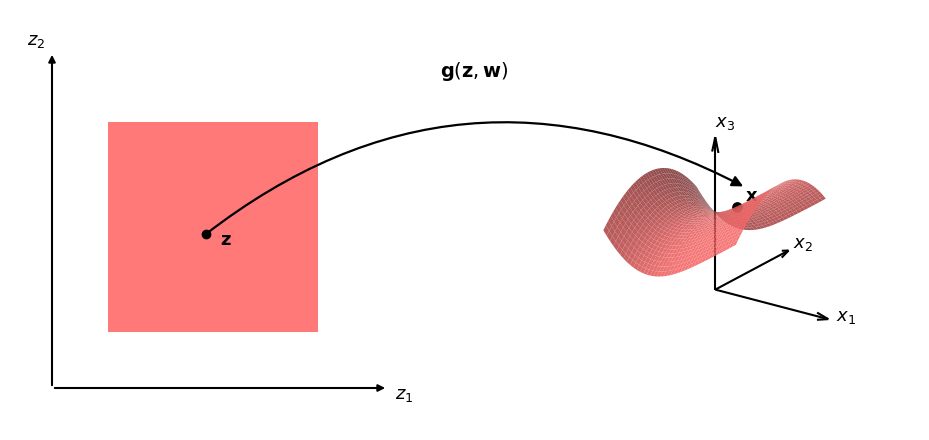

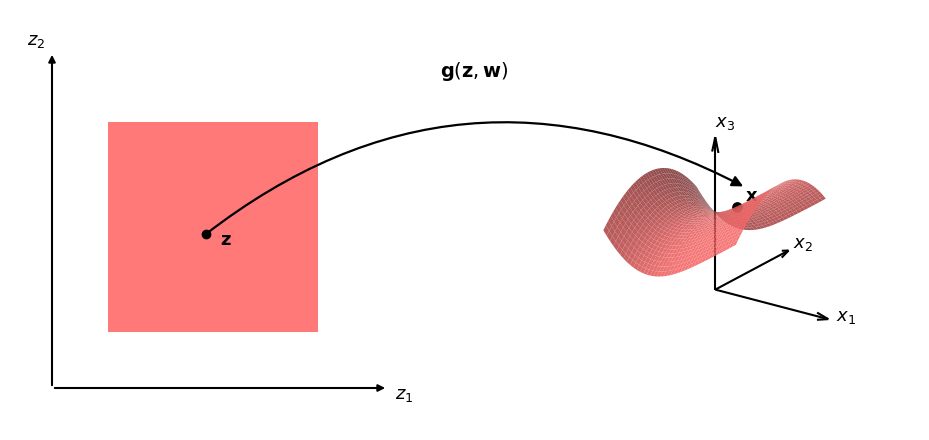

In [3]:
# Figure 16.11 の再現
fig_16_11 = generate_figure_16_11("result/fig_16_11_nonlinear_manifold.png")
generate_figure_16_11("16/result/fig_16_11_nonlinear_manifold.png")
plt.show()


#### 零確率密度問題と条件付きガウス分布の導入

決定論的な写像 $\mathbf{x} = \mathbf{g}(\mathbf{z}, \mathbf{w})$ のみでは、多様体の外側にある空間全体の確率密度が厳密に $0$ になってしまいます。実データには測定ノイズや多様体からの微小なズレが含まれるため、多様体上に厳密に乗らない任意のデータ点に対して尤度がゼロになり、勾配降下法による学習が破綻します。

そこで、回帰モデルや線形PPCAと同様に、多様体の周りに等方的なガウス観測ノイズ $\sigma^2 \mathbf{I}$ を付加し、空間全体で定義される条件付き分布を導入します：
$$
p(\mathbf{x} \mid \mathbf{z}, \mathbf{w}) = \mathcal{N}(\mathbf{x} \mid \mathbf{g}(\mathbf{z}, \mathbf{w}), \sigma^2 \mathbf{I}) \tag{16.80}
$$
ここで、ジェネレータニューラルネットワーク $\mathbf{g}(\mathbf{z}, \mathbf{w}) \in \mathbb{R}^D$ は線形出力活性化関数を持ちます。

#### Figure 16.12: 非線形潜在変数モデルのグラフィカルモデル
潜在変数 $\mathbf{z}$ と観測変数 $\mathbf{x}$ の結合分布は $p(\mathbf{x}, \mathbf{z}) = p(\mathbf{x} \mid \mathbf{z}) p(\mathbf{z})$ であり、以下の有向グラフィカルモデルで表現されます。


Figure saved successfully to: result/fig_16_12_nonlinear_latent_graphical_model.png
Figure saved successfully to: 16/result/fig_16_12_nonlinear_latent_graphical_model.png


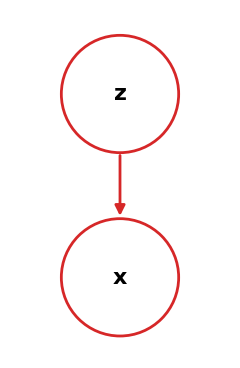

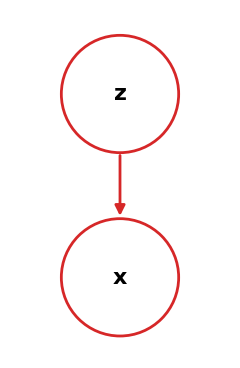

In [4]:
# Figure 16.12 の再現
fig_16_12 = generate_figure_16_12("result/fig_16_12_nonlinear_latent_graphical_model.png")
generate_figure_16_12("16/result/fig_16_12_nonlinear_latent_graphical_model.png")
plt.show()


#### 効率的な順方向サンプリング (Ancestral Sampling)
このモデルからのサンプリングは極めて高速かつ非反復的に実行可能です：
1. 事前分布から潜在変数をサンプリング： $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$
2. ニューラルネットワークの順伝播により平均を計算： $\boldsymbol{\mu}_x = \mathbf{g}(\mathbf{z}, \mathbf{w})$
3. 観測ノイズを付加してサンプルを生成： $\mathbf{x} \sim \mathcal{N}(\boldsymbol{\mu}_x, \sigma^2 \mathbf{I})$

#### 周辺分布の積分 (Marginal Distribution)
観測変数 $\mathbf{x}$ の周辺分布は、潜在変数 $\mathbf{z}$ を周辺化（積分消去）することで得られます：
$$
p(\mathbf{x}) = \int p(\mathbf{z}) p(\mathbf{x} \mid \mathbf{z}) d\mathbf{z} \tag{16.81}
$$

#### Figure 16.13: 1次元潜在空間と2次元円環データ空間
Bishop教科書で示される具体的なトイモデルとして、$M=1, D=2$、写像 $\mathbf{g}(z) = (\sin z, \cos z)^T$、ノイズ標準偏差 $\sigma = 0.3$ を考えます。
- (a) 潜在空間の事前分布 $p(z) = \mathcal{N}(z \mid 0, 1)$
- (b) $z = -1.8, 0, +1.8$ における条件付き分布 $p(\mathbf{x} \mid z)$、平均の軌跡（円弧）、および右端の周辺分布 $p(\mathbf{x})$


Figure saved successfully to: result/fig_16_13_nonlinear_latent_variable_model.png


Figure saved successfully to: 16/result/fig_16_13_nonlinear_latent_variable_model.png


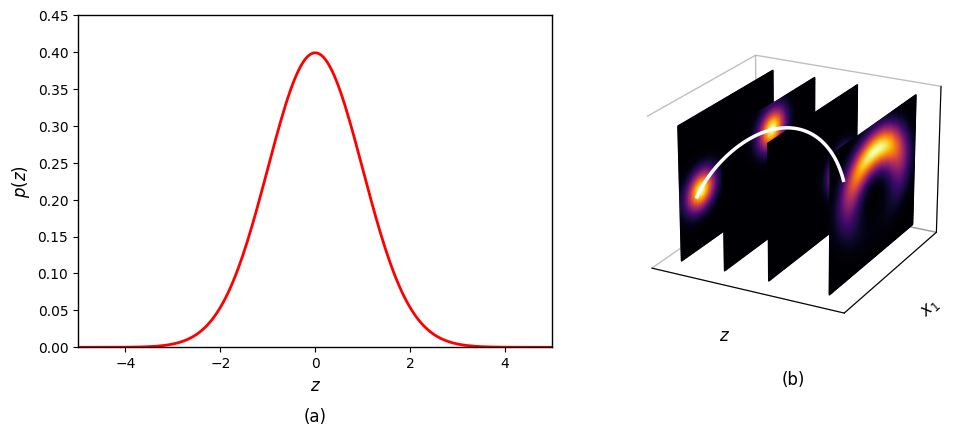

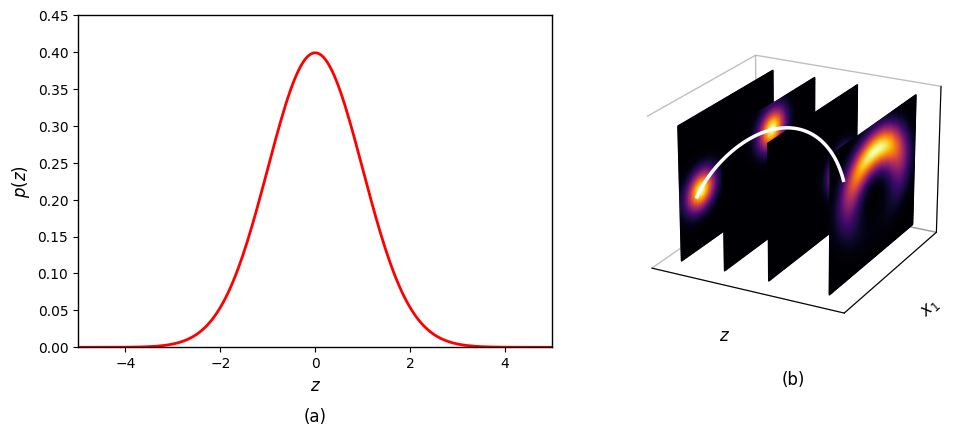

In [5]:
# Figure 16.13 の再現
fig_16_13 = generate_figure_16_13("result/fig_16_13_nonlinear_latent_variable_model.png")
generate_figure_16_13("16/result/fig_16_13_nonlinear_latent_variable_model.png")
plt.show()


In [6]:
# 円環多様体モデルの数値積分による全確率の検証
circle_model = CircleManifoldModel(sigma=0.3)
x_span = np.linspace(-2.5, 2.5, 80)
grid_density = circle_model.marginal_density_grid(x_span, x_span, num_quad_points=100)

dx = x_span[1] - x_span[0]
total_mass = np.sum(grid_density) * (dx ** 2)
print(f"2次元周辺密度の2重積分値: {total_mass:.4f} (理論値: 1.0000)")


2次元周辺密度の2重積分値: 0.9999 (理論値: 1.0000)


---
### 16.4.2 尤度関数 (Likelihood Function)

観測データ集合 $\mathbf{X} = \{\mathbf{x}_n\}$ に対する最尤推定を考えます。
単一データ点に対する尤度関数は、同時分布を潜在空間全体にわたって積分することで与えられます：
$$
\begin{align}
p(\mathbf{x} \mid \mathbf{w}) &= \int p(\mathbf{x} \mid \mathbf{z}, \mathbf{w}) p(\mathbf{z}) d\mathbf{z} \\
&= \int \mathcal{N}(\mathbf{x} \mid \mathbf{g}(\mathbf{z}, \mathbf{w}), \sigma^2 \mathbf{I}) \mathcal{N}(\mathbf{z} \mid \mathbf{0}, \mathbf{I}) d\mathbf{z} \tag{16.82}
\end{align}
$$

#### 解析的不可能性 (Analytical Intractability)
被積分関数の2つの因子はいずれもガウス分布ですが、平均 $\mathbf{g}(\mathbf{z}, \mathbf{w})$ が深層ニューラルネットワークという高度に非線形な関数であるため、この積分は**解析的に閉じた形で解くことができません**。

#### モンテカルロ近似とその限界
単純なモンテカルロ積分によって尤度を近似することを試みます：
$$
p(\mathbf{x} \mid \mathbf{w}) \simeq \frac{1}{K} \sum_{i=1}^K p(\mathbf{x} \mid \mathbf{z}_i, \mathbf{w}), \quad \mathbf{z}_i \sim p(\mathbf{z}) \tag{16.83}
$$
これは固定の重み $1/K$ を持つガウス混合モデルとしての表現であり、$K \to \infty$ の極限では真の尤度に収束します。

しかし、高次元データ空間において**有効な近似を得るために必要なサンプル数 $K$ は天文学的な数になり、実用上全く機能しません**。

#### Figure 16.14: ピクセル単位のユークリッド距離の破綻 (Doersch 2016)
手書き数字 '2' の3枚の画像を用いて、なぜランダムサンプリングによる尤度評価が失敗するのかを考察します：
- (a) 元のターゲット画像 $\mathbf{x}_a$
- (b) 下部ストロークの一部が欠落した破損画像 $\mathbf{x}_b$
- (c) 元画像を右下にわずか半ピクセルだけ平行移動した画像 $\mathbf{x}_c$


Figure saved successfully to: result/fig_16_14_pixel_distance_failure.png


Figure saved successfully to: 16/result/fig_16_14_pixel_distance_failure.png


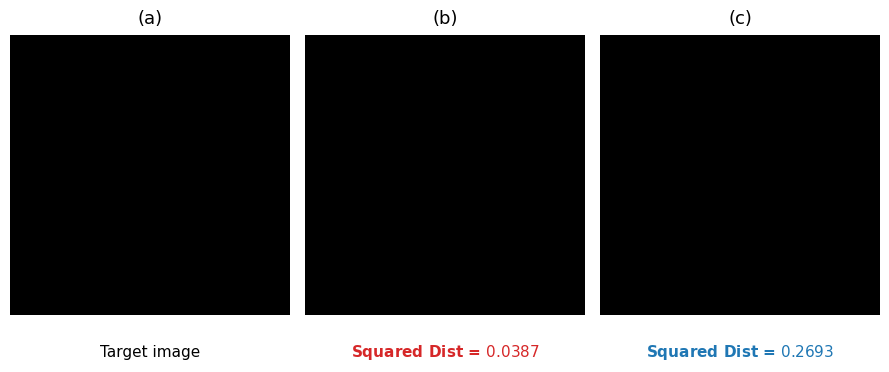

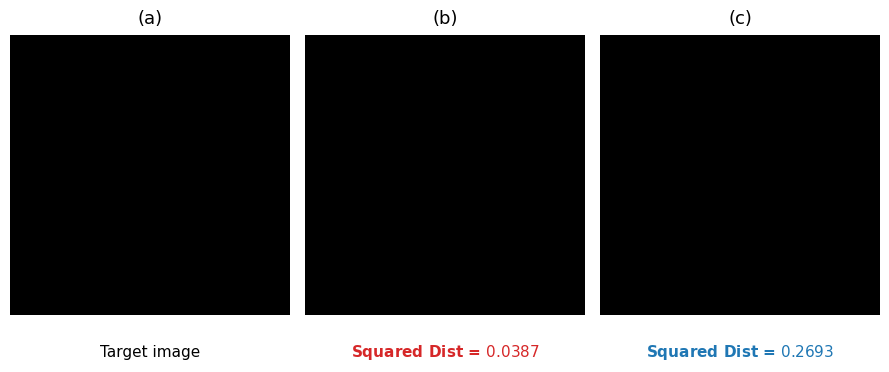

In [7]:
# Figure 16.14 の再現
fig_16_14 = generate_figure_16_14("result/fig_16_14_pixel_distance_failure.png")
generate_figure_16_14("16/result/fig_16_14_pixel_distance_failure.png")
plt.show()


#### なぜピクセル二乗誤差は知覚的類似度と乖離するのか？
ガウス尤度関数 $\mathcal{N}(\mathbf{x} \mid \hat{\mathbf{x}}, \sigma^2 \mathbf{I})$ は、ピクセル値の二乗誤差 $\|\mathbf{x} - \hat{\mathbf{x}}\|^2$ の指数関数に比例します：
$$
p(\mathbf{x} \mid \hat{\mathbf{x}}) \propto \exp\left( - \frac{\|\mathbf{x} - \hat{\mathbf{x}}\|^2}{2\sigma^2} \right)
$$

教科書の数値計算結果：
- 元画像 (a) と破損画像 (b) の二乗誤差: $d^2(a, b) = 0.0387$
- 元画像 (a) と半ピクセル移動画像 (c) の二乗誤差: $d^2(a, c) = 0.2693$

画像 (c) は人間が見るとほぼ完璧な '2' であるにもかかわらず、急峻なエッジが半ピクセルずれるだけで全エッジ部分で誤差が発生するため、**二乗誤差は破損画像 (b) の約 7 倍も大きく**なります。
その結果、ノイズパラメータ $\sigma^2$ を小さく設定すると、破損画像 (b) よりも高品質な画像 (c) の尤度の方が指数関数的に圧倒的に小さくなってしまいます。

したがって、潜在空間からの単純ランダムサンプリングによってターゲット画像 (a) の近傍に偶然ヒットする確率は極めて低く、より洗練された推論手法（変分推論など）が必要となります。


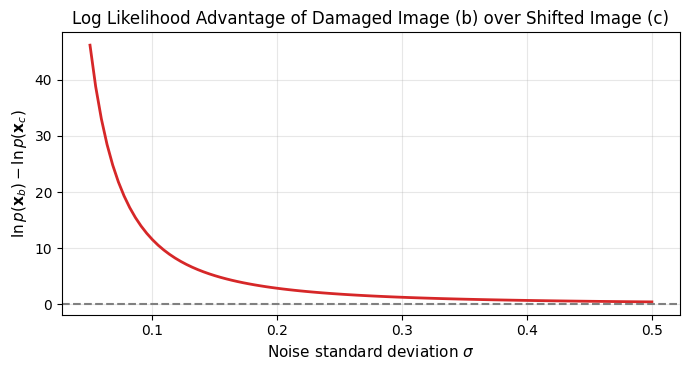

In [8]:
# ノイズ標準偏差 sigma に対する尤度比の数値解析
sigmas = np.linspace(0.05, 0.5, 100)
d2_b = 0.0387
d2_c = 0.2693

# 相対対数尤度差: ln p(b) - ln p(c) = (d2_c - d2_b) / (2 * sigma^2)
log_likelihood_ratio = (d2_c - d2_b) / (2.0 * (sigmas ** 2))

plt.figure(figsize=(7, 3.8))
plt.plot(sigmas, log_likelihood_ratio, color='#d62728', lw=2.0)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel(r'Noise standard deviation $\sigma$', fontsize=11)
plt.ylabel(r'$\ln p(\mathbf{x}_b) - \ln p(\mathbf{x}_c)$', fontsize=11)
plt.title(r'Log Likelihood Advantage of Damaged Image (b) over Shifted Image (c)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
### 16.4.3 離散データ (Discrete Data)

実世界のデータは連続値だけでなく、二値（白黒画像、有無フラグ）やカテゴリカル変数（テキストトークン、クラスラベル）などの離散値をとる場合があります。

#### 1. 独立二値データに対するベルヌーイ観測モデル
各成分 $x_i \in \{0, 1\}$ が条件付き独立である場合、観測分布はベルヌーイ分布の積として定式化されます：
$$
p(\mathbf{x} \mid \mathbf{z}, \mathbf{w}) = \prod_{i=1}^D g_i(\mathbf{z}, \mathbf{w})^{x_i} \big(1 - g_i(\mathbf{z}, \mathbf{w})\big)^{1 - x_i} \tag{16.84}
$$
ここで、$g_i(\mathbf{z}, \mathbf{w}) = \sigma(a_i(\mathbf{z}, \mathbf{w}))$ はロジスティック・シグモイド関数であり、$a_i(\mathbf{z}, \mathbf{w})$ は第 $i$ 出力ユニットの事前活性化（ロジット）です。

#### 2. ワンホット・カテゴリカルデータに対する多項観測モデル
$D$ 次元のワンホットベクトル $\mathbf{x} \in \{0, 1\}^D$ ($\sum_{i=1}^D x_i = 1$) に対しては、多項分布（カテゴリカル分布）を用います：
$$
p(\mathbf{x} \mid \mathbf{z}, \mathbf{w}) = \prod_{i=1}^D g_i(\mathbf{z}, \mathbf{w})^{x_i} \tag{16.85}
$$
ここで、$g_i(\mathbf{z}, \mathbf{w})$ はソフトマックス活性化関数 (Softmax Activation) です：
$$
g_i(\mathbf{z}, \mathbf{w}) = \frac{\exp(a_i(\mathbf{z}, \mathbf{w}))}{\sum_{j=1}^D \exp(a_j(\mathbf{z}, \mathbf{w}))} \tag{16.86}
$$

#### 密度崩壊 (Density Collapse) と一様脱量子化 (Uniform Dequantization)
画像データ（RGB 各チャンネル 8 ビット: $\{0, 1, \dots, 255\}$）のように、本質的には連続的な物理量を離散化（量子化）して記録したデータを柔軟な深層ニューラルネットワークで連続密度モデルとして学習すると、離散格子点上に確率密度が無限大のスパイクとなって集中する**密度崩壊 (Density Collapse / Pathological Spike)** が発生します。

この問題を解決するのが**脱量子化 (Dequantization)** です。
各離散整数 $x \in \{0, \dots, 255\}$ に対し、区間幅の一様ノイズ $u \sim \mathcal{U}(0, 1)$ を加算して連続変数 $y = x + u$ に変換します：
$$
y = x + u, \quad u \sim \mathcal{U}(0, 1)
$$
これにより、離散確率分布 $P(x)$ は各ビン $[x, x+1)$ 上で平坦な確率密度 $p(y) = P(\lfloor y \rfloor)$ を持つ連続分布に変換され、密度の無限大発散が防止されます。

#### Figure 16.15: 脱量子化の模式図
- (a) 離散分布 $P(x)$ （狭いスパイク）
- (b) 一様ノイズを加えた連続脱量子化分布 $p(y)$ （ヒストグラム）


Figure saved successfully to: result/fig_16_15_dequantization.png
Figure saved successfully to: 16/result/fig_16_15_dequantization.png


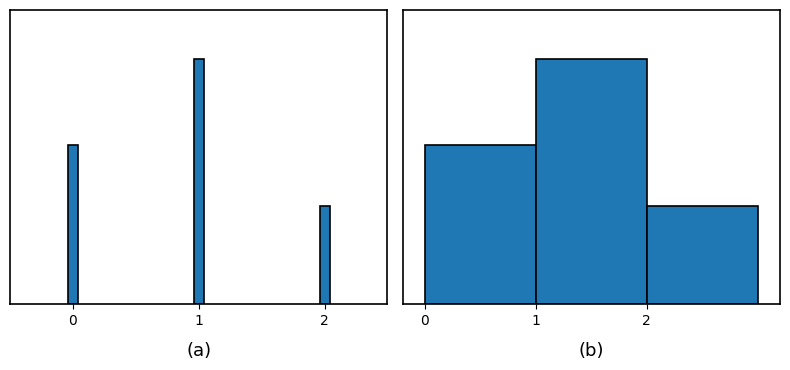

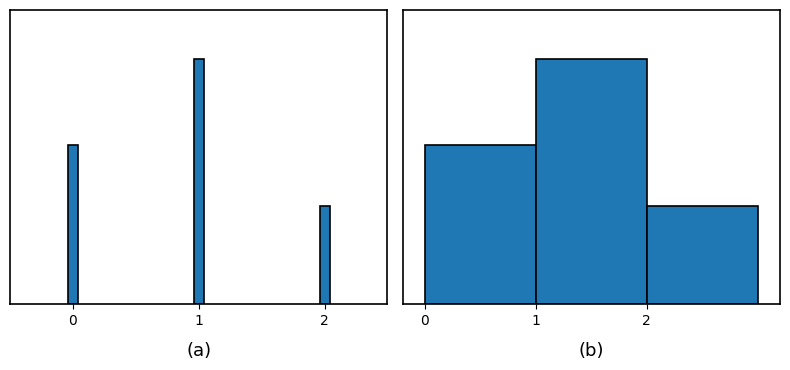

In [9]:
# Figure 16.15 の再現
fig_16_15 = generate_figure_16_15("result/fig_16_15_dequantization.png")
generate_figure_16_15("16/result/fig_16_15_dequantization.png")
plt.show()


In [10]:
# 脱量子化アルゴリズムの動作検証
discrete_vals = np.array([0, 1, 2, 100, 255])
dequantized_vals = uniform_dequantize(discrete_vals, scale=1.0, rng=np.random.RandomState(42))

for d, c in zip(discrete_vals, dequantized_vals):
    print(f"離散値: {d:3d}  -->  脱量子化連続値: {c:.4f} (区間 [{d}, {d+1}) 内)")


離散値:   0  -->  脱量子化連続値: 0.3745 (区間 [0, 1) 内)
離散値:   1  -->  脱量子化連続値: 1.9507 (区間 [1, 2) 内)
離散値:   2  -->  脱量子化連続値: 2.7320 (区間 [2, 3) 内)
離散値: 100  -->  脱量子化連続値: 100.5987 (区間 [100, 101) 内)
離散値: 255  -->  脱量子化連続値: 255.1560 (区間 [255, 256) 内)


---
### 16.4.4 生成モデリングへの4つのアプローチ (Four Approaches to Generative Modelling)

深層ニューラルネットワークに基づく非線形潜在変数モデルは、万能近似定理 (Universal Approximation Theorem) により原理上あらゆる複雑なデータ分布を近似できる驚異的な柔軟性を持ちます。
しかし、前述の「可逆性の制限」や「周辺尤度積分の解析的不可能性」という本質的課題に対処するため、近代機械学習では大きく**4つの異なるアプローチ**が発展してきました。
本書の続く4つの章（第17章〜第20章）では、これら4大パラダイムを1つずつ詳細に探求します。

| アプローチ | 対象章 | ネットワーク構造の要件 | 尤度評価 | サンプリング効率 | 主な特徴と課題 |
|---|:---:|---|:---:|:---:|---|
| **敵対的生成ネットワーク (GAN)** | **第17章** | 制限なし (任意の生成器 $g$) + 識別器 $d$ | 尤度関数なし (評価不可) | 高速 (1ステップ順伝播) | ゼロサムゲームによる敵対的学習。高品質だが最大学習不安定性・モード崩壊リスクあり。 |
| **変分自己符号化器 (VAE)** | **第19章** | 生成器 (Decoder) + 推論器 (Encoder) | 証拠下界 (ELBO) による近似評価 | 高速 (1ステップ順伝播) | 変分事後分布 $q(\mathbf{z}\mid\mathbf{x})$ で尤度下界を最大化。安定した学習だがぼやけやすい。 |
| **正規化フロー (Normalizing Flows)** | **第18章** | 同次元かつ可逆 ($M=D$, Bijective) | 変数変換公式による厳密評価 | 高速 (逆伝播または順伝播) | ヤコビアン行列式の計算制約があるが、厳密な負の対数尤度を直接最小化可能。 |
| **拡散モデル (Diffusion Models)** | **第20章** | ノイズ予測器 (スコアベース) | 変分下界 / スコア一致 | 比較的低速 (数十〜数百ステップのデノイジング) | 前方向ガウス拡散と逆方向デノイジング過程。現在最高峰の生成品質と学習安定性。 |

---
### 本節のまとめと結論

1. **非線形の必然性**:
   線形潜在変数モデル（PCA, PPCA, 因子分析）は厳密な解析解やEMアルゴリズムを持つが、高次元データが内在する非線形多様体を捉えきれない。
2. **生成モデルの定式化**:
   潜在ガウス事前分布 $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ とニューラルネットワーク観測分布 $\mathbf{x} \mid \mathbf{z} \sim \mathcal{N}(\mathbf{g}(\mathbf{z}, \mathbf{w}), \sigma^2 \mathbf{I})$ により、空間全体の密度を矛盾なくモデル化できる。
3. **最尤学習の壁**:
   非線形性により周辺尤度 $\int p(\mathbf{x}\mid\mathbf{z})p(\mathbf{z})d\mathbf{z}$ は解析不能となり、単純モンテカルロ法は「次元の呪い」と「ピクセルユークリッド距離の破綻」によって完全に失効する。
4. **4大生成モデルへの昇華**:
   この根本的課題を突破するために考案された4つの天才的な戦略（GAN, VAE, Normalizing Flow, Diffusion）が、現代の深層生成AI革命の中核を形成している。
